In [1]:
import pandas as pd
import numpy as np

In [2]:
dataset=pd.read_csv("placement.csv")

In [3]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


#  1)Replace the NaN values. And justify your choise

In [4]:
# First, we need to perform data preprocessing, which involves two tasks:
# 1. Identify and remove null values.
# 2. Identify and remove outliers.

In [5]:
# to find the null values
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [6]:
null_salary_df = dataset[dataset['salary'].isnull()]

print(f"Total rows with null salary : {len(null_salary_df)}")
print()

Total rows with null salary : 67



In [7]:
null_salary_df

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
3,4,M,56.0,Central,52.0,Central,Science,52.00,Sci&Tech,No,66.00,Mkt&HR,59.43,Not Placed,NaN
5,6,M,55.0,Others,49.8,Others,Science,67.25,Sci&Tech,Yes,55.00,Mkt&Fin,51.58,Not Placed,NaN
6,7,F,46.0,Others,49.2,Others,Commerce,79.00,Comm&Mgmt,No,74.28,Mkt&Fin,53.29,Not Placed,NaN
9,10,M,58.0,Central,70.0,Central,Commerce,61.00,Comm&Mgmt,No,54.00,Mkt&Fin,52.21,Not Placed,NaN
12,13,F,47.0,Central,55.0,Others,Science,65.00,Comm&Mgmt,No,62.00,Mkt&HR,65.04,Not Placed,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,199,F,67.0,Central,70.0,Central,Commerce,65.00,Others,No,88.00,Mkt&HR,71.96,Not Placed,NaN
201,202,M,54.2,Central,63.0,Others,Science,58.00,Comm&Mgmt,No,79.00,Mkt&HR,58.44,Not Placed,NaN
206,207,M,41.0,Central,42.0,Central,Science,60.00,Comm&Mgmt,No,97.00,Mkt&Fin,53.39,Not Placed,NaN
208,209,F,43.0,Central,60.0,Others,Science,65.00,Comm&Mgmt,No,92.66,Mkt&HR,62.92,Not Placed,NaN


In [8]:
print("Unique status values for null salary rows:")
print(null_salary_df['status'].unique())

Unique status values for null salary rows:
['Not Placed']


In [9]:
# Those who are not placed are not receiving a salary, so to replace the null values in the "salary" column, we can assign them a value of zero.

dataset["salary"].fillna(0,inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_6256\4217729059.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset["salary"].fillna(0,inplace=True)


In [10]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [11]:
categorical_cols = dataset.select_dtypes(include=['object', 'category']).columns
numerical_cols = dataset.select_dtypes(exclude=['object', 'category']).columns

In [12]:
categorical_cols

Index(['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex',
       'specialisation', 'status'],
      dtype='object')

In [13]:
numerical_cols

Index(['sl_no', 'ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary'], dtype='object')

In [14]:
Quan=['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

Qual=['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex','specialisation', 'status']

# handling the outliers

In [15]:
des=dataset.describe()

In [16]:
des

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,198702.325581
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,154780.926716
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,0.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,0.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,240000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,282500.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


In [17]:
descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lower_Bound","Upper_Bound","Min","Max"],columns=Quan)

for columnName in Quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]= descriptive[columnName]["Q3:75%"]- descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lower_Bound"]=descriptive[columnName]["Q1:25%"]- descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Upper_Bound"] = descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"] = dataset[columnName].min()
    descriptive[columnName]["Max"] = dataset[columnName].max()

C:\Users\HP\AppData\Local\Temp\ipykernel_6256\2824079916.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  descriptive[columnName]["Mean"]=dataset[columnName].mean()
C:\Users\HP\AppData\Local\Temp\ipykernel_6256\2824079916.py:5: FutureWarn

In [18]:
descriptive

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,67.303395,66.333163,66.370186,72.100558,62.278186,198702.325581
Median,67.0,65.0,66.0,71.0,62.0,240000.0
Mode,62.0,63.0,65.0,60.0,56.7,0.0
Q1:25%,60.6,60.9,61.0,60.0,57.945,0.0
Q2:50%,67.0,65.0,66.0,71.0,62.0,240000.0
Q3:75%,75.7,73.0,72.0,83.5,66.255,282500.0
Q4:100%,89.4,97.7,91.0,98.0,77.89,940000.0
IQR,15.1,12.1,11.0,23.5,8.31,282500.0
1.5rule,22.65,18.15,16.5,35.25,12.465,423750.0
Lower_Bound,37.95,42.75,44.5,24.75,45.48,-423750.0


In [19]:
LesserOut=[]
GreaterOut=[]

for columnName in Quan:
    if descriptive.loc["Lower_Bound", columnName] > descriptive.loc["Min", columnName]:
        LesserOut.append(columnName)
    if descriptive.loc["Upper_Bound", columnName] < descriptive.loc["Max", columnName]:
        GreaterOut.append(columnName)

In [20]:
LesserOut

['hsc_p']

In [21]:
GreaterOut

['hsc_p', 'degree_p', 'salary']

In [22]:
for columnName in LesserOut:
    dataset.loc[dataset[columnName] < descriptive[columnName]["Lower_Bound"], columnName] = descriptive[columnName]["Lower_Bound"]

for columnName in GreaterOut:
    dataset.loc[dataset[columnName] > descriptive[columnName]["Upper_Bound"], columnName] = descriptive[columnName]["Upper_Bound"]

In [23]:
dataset["hsc_p"].max()

np.float64(91.15)

In [24]:
# Since the outliers have been updated, we also need to update our descriptive table.

descriptive=pd.DataFrame(index=["Mean","Median","Mode","Q1:25%","Q2:50%","Q3:75%","Q4:100%","IQR","1.5rule","Lower_Bound","Upper_Bound","Min","Max"],columns=Quan)

for columnName in Quan:
    descriptive[columnName]["Mean"]=dataset[columnName].mean()
    descriptive[columnName]["Median"]=dataset[columnName].median()
    descriptive[columnName]["Mode"]=dataset[columnName].mode()[0]
    descriptive[columnName]["Q1:25%"]=dataset.describe()[columnName]["25%"]
    descriptive[columnName]["Q2:50%"]=dataset.describe()[columnName]["50%"]
    descriptive[columnName]["Q3:75%"]=dataset.describe()[columnName]["75%"]
    descriptive[columnName]["Q4:100%"]=dataset.describe()[columnName]["max"]
    descriptive[columnName]["IQR"]= descriptive[columnName]["Q3:75%"]- descriptive[columnName]["Q1:25%"]
    descriptive[columnName]["1.5rule"]=1.5*descriptive[columnName]["IQR"]
    descriptive[columnName]["Lower_Bound"]=descriptive[columnName]["Q1:25%"]- descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Upper_Bound"] = descriptive[columnName]["Q3:75%"]+descriptive[columnName]["1.5rule"]
    descriptive[columnName]["Min"] = dataset[columnName].min()
    descriptive[columnName]["Max"] = dataset[columnName].max()

C:\Users\HP\AppData\Local\Temp\ipykernel_6256\2700674060.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  descriptive[columnName]["Mean"]=dataset[columnName].mean()
C:\Users\HP\AppData\Local\Temp\ipykernel_6256\2700674060.py:7: FutureWarn

In [25]:
LesserOut=[]
GreaterOut=[]

for columnName in Quan:
    if descriptive.loc["Lower_Bound", columnName] > descriptive.loc["Min", columnName]:
        LesserOut.append(columnName)
    if descriptive.loc["Upper_Bound", columnName] < descriptive.loc["Max", columnName]:
        GreaterOut.append(columnName)

In [26]:
LesserOut

[]

In [27]:
GreaterOut

[]

In [28]:
# now the basic steps are done

#  2)How many of them are not placed?

In [29]:
dataset["status"].value_counts()

status
Placed        148
Not Placed     67
Name: count, dtype: int64

In [30]:
# the count of not placed is 67. or

dataset["status"].value_counts()["Not Placed"]

np.int64(67)

#  3)Find the reason for non placement from the dataset?

In [31]:
placed_df= dataset[dataset["status"]== "Placed"]
not_placed_df= dataset[dataset["status"]== "Not Placed"]
numeric_col=['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

comparison= pd.DataFrame({
    'Placed_Mean': placed_df[numeric_col].mean().round(2),
    'NotPlaced_Mean' : not_placed_df[numeric_col].mean().round(2) 
})

comparison['Difference'] = (comparison['Placed_Mean']- comparison['NotPlaced_Mean']).round(2)
print(comparison)

          Placed_Mean  NotPlaced_Mean  Difference
ssc_p           71.72           57.54       14.18
hsc_p           69.84           58.60       11.24
degree_p        68.72           61.13        7.59
etest_p         73.24           69.59        3.65
mba_p           62.58           61.61        0.97


In [32]:
from scipy.stats import ttest_ind
numaric_col=['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

for col in numaric_col:
    t, p = ttest_ind(placed_df[col], not_placed_df[col])
    result = "SIGNIFICANT ✅" if p < 0.05 else "NOT significant ❌"
    print(f"{col:12s} → t={t:.3f}, p={p:.4f} → {result}")

ssc_p        → t=11.173, p=0.0000 → SIGNIFICANT ✅
hsc_p        → t=8.267, p=0.0000 → SIGNIFICANT ✅
degree_p     → t=8.012, p=0.0000 → SIGNIFICANT ✅
etest_p      → t=1.878, p=0.0617 → NOT significant ❌
mba_p        → t=1.126, p=0.2614 → NOT significant ❌


In [33]:
Qual

['gender',
 'ssc_b',
 'hsc_b',
 'hsc_s',
 'degree_t',
 'workex',
 'specialisation',
 'status']

In [34]:
#From the categorical colums, the "workex" is very important, so we are analyzing it 

we_p = placed_df["workex"].value_counts(normalize=True)["Yes"]*100
we_np = not_placed_df["workex"].value_counts(normalize=True).get("Yes",0)*100
 
print(f'/n Work Experience - Placed: {we_p:.2f}% | Not Placed: {we_np:.2f}%')

/n Work Experience - Placed: 43.24% | Not Placed: 14.93%


CONCLUSION — Reasons for Non-Placement:
  * Lower academic scores (ssc_p, hsc_p , degree_p)
  * Far fewer students have work experience (14.93% vs 43.24%)

# 4)What kind of relation between salary and mba_p

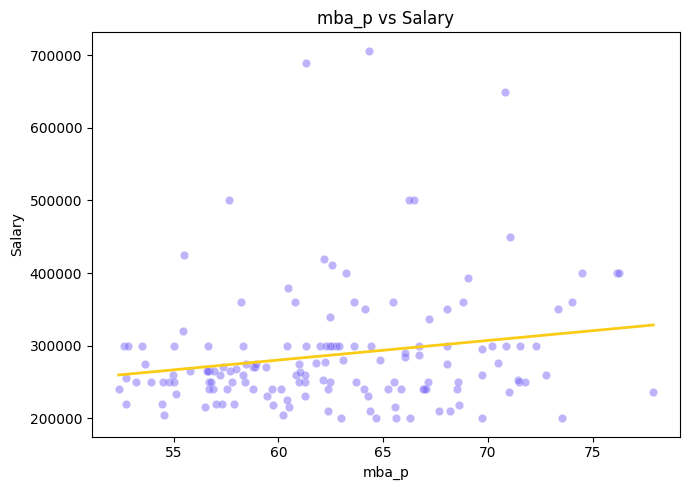

In [35]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(placed_df['mba_p'], placed_df['salary'],
           alpha=0.5, color='#7c6af7', edgecolors='white',
           linewidth=0.3)

# Add trend line
m, b = np.polyfit(placed_df['mba_p'], placed_df['salary'], 1)
x_line = np.linspace(placed_df['mba_p'].min(), placed_df['mba_p'].max(), 100)
ax.plot(x_line, m*x_line + b, color='#facc15', linewidth=2)

ax.set_xlabel('mba_p')
ax.set_ylabel('Salary')
ax.set_title('mba_p vs Salary')

plt.tight_layout()
plt.show()

In [36]:
from scipy import stats
corr, pval=stats.pearsonr(placed_df["salary"],placed_df['mba_p'])

print(f'Pearson r = {corr:.4f}')
print(f'p-value   = {pval:.4f}')

Pearson r = 0.1894
p-value   = 0.0212


 Pearson r = 0.1894 so, WEAK correlation
 Sign is positive (+) → POSITIVE direction
 Therefore: Weak Positiv Relationship

 p-value = 0.0212 < 0.05 (significance level α)
 → We REJECT the Null Hypothesis
 → The correlation is Statistically SIGNIFICANT
 → So,the relationship did not occur by chance

CONCLUSION
As MBA % increases, salary also increase — But the relationship is NOT strong enough to predict salary from MBA %
Many other factors influence salary more than MBA %

#  5)Which specialization is getting minimum salary?

In [37]:
dataset["specialisation"].value_counts()

specialisation
Mkt&Fin    120
Mkt&HR      95
Name: count, dtype: int64

In [38]:
min_salary = placed_df.groupby('specialisation')['salary'].min()
print(min_salary)

specialisation
Mkt&Fin    200000.0
Mkt&HR     200000.0
Name: salary, dtype: float64


In [39]:
min_salary = placed_df.groupby('specialisation')['salary'].agg(["mean", "min"])
min_salary.columns= ["Average Salary", "Min Salary"]
print(min_salary.round(2))

                Average Salary  Min Salary
specialisation                            
Mkt&Fin              296392.11    200000.0
Mkt&HR               270377.36    200000.0


Both specializations share the same minimum salary of 200000.0. However, when comparing groups, the mean (average) is the appropriate measure of
central tendency to use.
Based on the mean salary comparison, Mkt&HR specialization records the lower average salary of  270377.36 compared to Mkt&Fin at 296392.11 . 
Therefore, Mkt&HR receivesthe minimum average salary among the two specializations.    

# 6)How many of them getting above 500000 salary?

In [40]:
above_500K = (placed_df['salary'] > 500000).sum()
print(above_500K)


3


Only 3 students are getting salary over 500K

# 7)Test the Analysis of Variance between etest_p and mba_p at signifance
#   level 5%.(Make decision using Hypothesis Testing)

Null Hypothesis (H0): There is no significant difference between the means of etest_p and mba_p.
    
Alternative Hypothesis (H1): There is a significant difference between the means of etest_p and mba_p.

In [41]:
import scipy.stats as stats

t_statistic, p_value = stats.ttest_rel(dataset["etest_p"],dataset["mba_p"])

print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print()

if p_value < 0.05:
    print(" P-Value <0.05 --> Reject the Null Hypothesis")
    print(" Signigicant difference beteween etest_p and mba_p means")
else:
    print("P-Value > 0.05 --> Fail to reject the Null Hypothesis")
    print("No significant difference")

T-statistic: 10.8407
P-value: 0.000000

 P-Value <0.05 --> Reject the Null Hypothesis
 Signigicant difference beteween etest_p and mba_p means


In [42]:
f_statistic, p_value = stats.f_oneway(dataset["etest_p"],dataset["mba_p"])

print(f"F-statistic: {f_statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print()

if p_value < 0.05:
    print(" P-Value <0.05 --> Reject the Null Hypothesis")
    print(" Signigicant difference beteween etest_p and mba_p means")
else:
    print("P-Value > 0.05 --> Fail to reject the Null Hypothesis")
    print("No significant difference")

F-statistic: 98.6449
P-value: 0.000000

 P-Value <0.05 --> Reject the Null Hypothesis
 Signigicant difference beteween etest_p and mba_p means


# 8)Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.(Make decision using Hypothesis Testing)

H0 : No significant salary difference between Sci&Tech and Mkt&HR

H1 : Significant salary difference exists between Sci&Tech and Mkt&HR

In [43]:
sci_tech_sal = placed_df[placed_df['degree_t'] == 'Sci&Tech']['salary']
mkt_hr_sal   = placed_df[placed_df['specialisation'] == 'Mkt&HR']['salary']

t_stat, p_ttest = ttest_ind(sci_tech_sal, mkt_hr_sal, equal_var=False)

print(f'Sci&Tech  — Number of Students = {len(sci_tech_sal)},  Mean={sci_tech_sal.mean():,.0f}')
print(f'Mkt&HR    — Number of Students = {len(mkt_hr_sal)},  Mean={mkt_hr_sal.mean():,.0f}')
print(f'\nT-statistic : {t_stat:.4f}')
print(f'p-value     : {p_ttest:.4f}')
print()

Sci&Tech  — Number of Students = 41,  Mean=314,610
Mkt&HR    — Number of Students = 53,  Mean=270,377

T-statistic : 2.5503
p-value     : 0.0134



In [44]:
if p_ttest < 0.05:
    print(f'\nP_Value < 0.05 so, We reject the Null Hypothis')
    print(f'Sci&Tech specialization earn significantly more than Mkt&HR specialization')
else:
    print(f'P_Value > 0.05 so, We fail to reject the null hypothesis')


P_Value < 0.05 so, We reject the Null Hypothis
Sci&Tech specialization earn significantly more than Mkt&HR specialization


#  9)Convert the normal distribution to standard normal distribution for salary column

In [45]:
placed_df_std= placed_df.copy()

mu    = placed_df_std['salary'].mean()
sigma = placed_df_std['salary'].std()

print(f'The mean of the salary : {mu:,.2f}')
print(f'The Std of the salary : {sigma:,.2f}')

placed_df_std['standard_salary'] = (placed_df['salary'] - mu) / sigma

print(f'\nAfter Standardization')
print(f"Mean : {placed_df_std['standard_salary'].mean():.6f}")  
print(f"Std  : {placed_df_std['standard_salary'].std():.6f}")
print()

The mean of the salary : 287,076.01
The Std of the salary : 83,857.17

After Standardization
Mean : 0.000000
Std  : 1.000000



In [46]:
placed_df_std

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary,standard_salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0,-0.203632
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0,-1.038385
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0,-0.442133
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0,1.644749
7,8,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.0,Mkt&Fin,62.14,Placed,252000.0,-0.418283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,210,M,62.00,Central,72.00,Central,Commerce,65.00,Comm&Mgmt,No,67.0,Mkt&Fin,56.49,Placed,216000.0,-0.847584
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0,1.346623
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0,-0.144007
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0,0.094494


# 10)What is the probability Density Function of the salary range from 700000 to 900000?

In [47]:
from scipy.stats import norm

mu    = placed_df['salary'].mean()
sigma = placed_df['salary'].std()

x1 = 700000
x2 = 900000

z1 = (x1 - mu)/sigma
z2 = (x2 - mu)/ sigma

prob = norm.cdf(z2) - norm.cdf(z1)

print(f'{prob*100:.6f}%')

0.000042%


In [48]:
actual = placed_df[
    (placed_df['salary'] >= 700000) & 
    (placed_df['salary'] <= 900000)
]
print(actual['salary'].value_counts())

salary
706250.0    1
Name: count, dtype: int64


The probability of a placed student earning between ₹7,00,000 and ₹9,00,000 is nearly zero (0.000042% is ~ 0%).
When verified against the actual dataset, only 1 student earns in this range, which confirms the near-zero probability."

# 11)Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

H₀ : There is no significant difference between etest_p and mba_p for Sci&Tech degree students (α = 0.05)

H₁ : There is a significant difference between etest_p and mba_p for Sci&Tech degree students (α = 0.05)

In [49]:
sci_tech_etest = dataset[dataset['degree_t'] == 'Sci&Tech']["etest_p"]
sci_tech_mba   = dataset[dataset['degree_t'] == 'Sci&Tech']['mba_p']

print(f'Mean of Sci&Tech Students etest_p : {sci_tech_etest.mean().round(2)}')
print(f'Mean of Sci&Tech Students mba_p   : {sci_tech_mba.mean().round(2)}')

t_stat, p_val = stats.ttest_rel(sci_tech_etest, sci_tech_mba)

print(f'\nT-statistic : {t_stat:.4f}')
print(f'p-value     : {p_val:.4f}')

Mean of Sci&Tech Students etest_p : 72.31
Mean of Sci&Tech Students mba_p   : 63.46

T-statistic : 5.0050
p-value     : 0.0000


In [50]:
if p_val <0.05:
    print(f'\np-value < 0.05 so, Reject the null Hypothesis')
    print(f'There is a significant difference between etest_p and mba_p for Sci&Tech degree students')
else:
    print(f'p_value > 0.05 so, Fail to reject the null Hypothesis')


p-value < 0.05 so, Reject the null Hypothesis
There is a significant difference between etest_p and mba_p for Sci&Tech degree students


#  12)Which parameter is highly correlated with salary?

# Find the correlaton for the numarical columns

In [51]:
Quan

['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

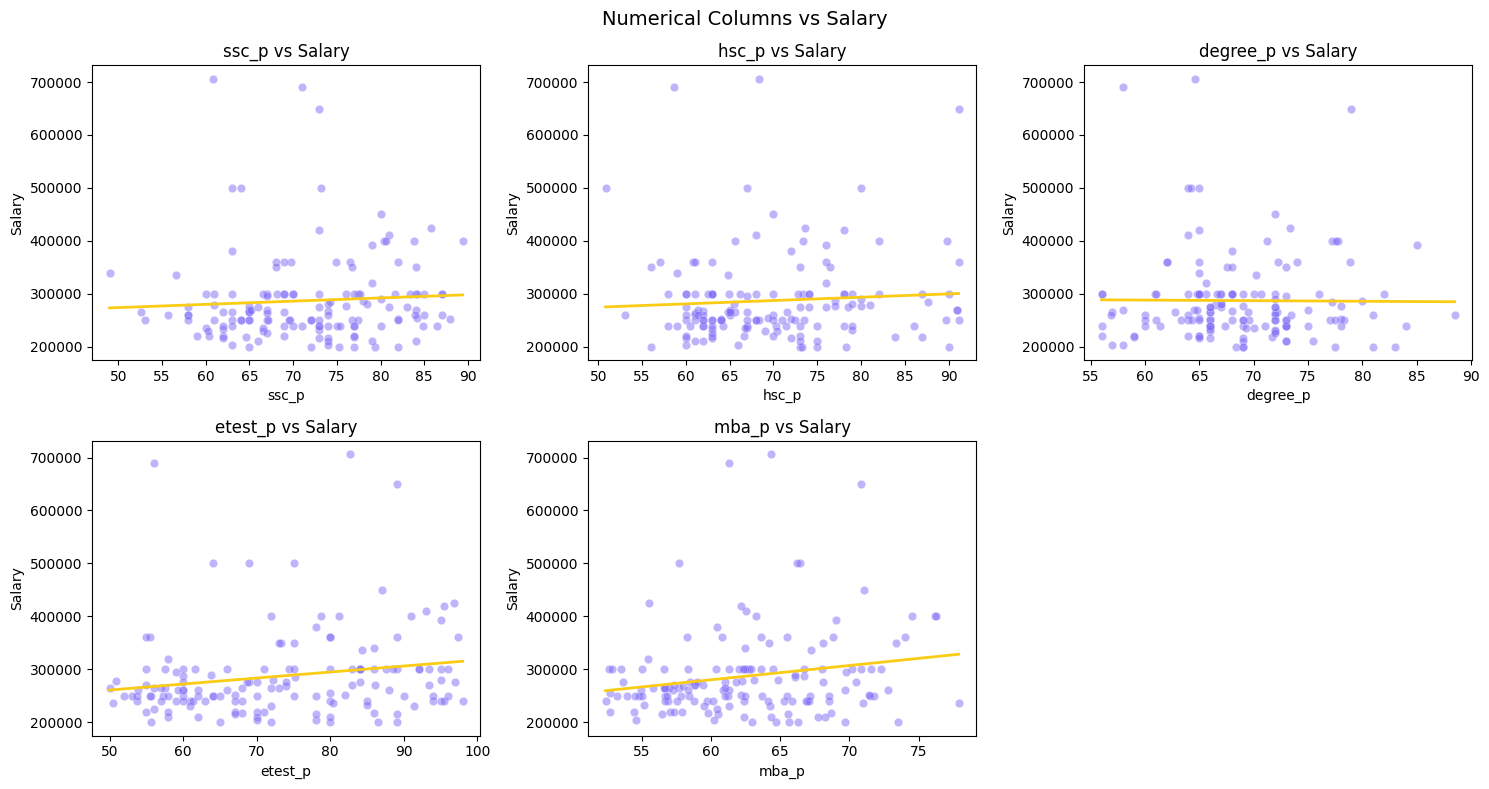

In [52]:
import matplotlib.pyplot as plt

num_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(placed_df[col], placed_df['salary'],
                    alpha=0.5, color='#7c6af7', edgecolors='white',
                    linewidth=0.3)
    
    # Add trend line
    m, b = np.polyfit(placed_df[col], placed_df['salary'], 1)
    x_line = np.linspace(placed_df[col].min(), 
                          placed_df[col].max(), 100)
    axes[i].plot(x_line, m*x_line + b, 
                 color='#facc15', linewidth=2)
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Salary')
    axes[i].set_title(f'{col} vs Salary')

# Hide last empty subplot
axes[-1].set_visible(False)
plt.suptitle('Numerical Columns vs Salary', fontsize=14)
plt.tight_layout()
plt.show()

In [53]:
# all are linear patter so, we are using the pearson_r methode

nume_cols   = ['ssc_p','hsc_p','degree_p','etest_p','mba_p','salary']
corr_matrix = placed_df[nume_cols].corr()
sal_corr    = corr_matrix['salary'].drop('salary').abs().sort_values(ascending=False)

print('Correlation with Salary (Placed students):')
print(sal_corr.round(4))
print(f'\n→ "{sal_corr.idxmax()}" is MOST correlated with Salary (r={sal_corr.max():.4f})')

Correlation with Salary (Placed students):
mba_p       0.1894
etest_p     0.1857
hsc_p       0.0681
ssc_p       0.0631
degree_p    0.0087
Name: salary, dtype: float64

→ "mba_p" is MOST correlated with Salary (r=0.1894)


In [54]:
nume_corr=placed_df.corr(numeric_only=True)

In [55]:
nume_corr

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
sl_no,1.000000,-0.093480,-0.222931,-0.107072,0.041467,-0.072432,0.066963
ssc_p,-0.093480,1.000000,0.297314,0.380205,0.317892,0.430560,0.063137
hsc_p,-0.222931,0.297314,1.000000,0.218938,0.277477,0.322447,0.068105
degree_p,-0.107072,0.380205,0.218938,1.000000,0.222206,0.495115,-0.008664
etest_p,0.041467,0.317892,0.277477,0.222206,1.000000,0.284143,0.185707
mba_p,-0.072432,0.430560,0.322447,0.495115,0.284143,1.000000,0.189376
salary,0.066963,0.063137,0.068105,-0.008664,0.185707,0.189376,1.000000


# Find the correlation for the categorical columns

In [56]:
Qual

['gender',
 'ssc_b',
 'hsc_b',
 'hsc_s',
 'degree_t',
 'workex',
 'specialisation',
 'status']

In [57]:
for col in Qual:
    print(f'{col:15s} : {placed_df[col].unique()}')

gender          : ['M' 'F']
ssc_b           : ['Others' 'Central']
hsc_b           : ['Others' 'Central']
hsc_s           : ['Commerce' 'Science' 'Arts']
degree_t        : ['Sci&Tech' 'Comm&Mgmt' 'Others']
workex          : ['No' 'Yes']
specialisation  : ['Mkt&HR' 'Mkt&Fin']
status          : ['Placed']


In [58]:
binary_cols = []
multi_cols  = []

for col in Qual:
    unique_count = placed_df[col].nunique()
    
    if unique_count == 2:
        binary_cols.append(col)
    if unique_count >= 3:
        multi_cols.append(col)

print("Binary Columns (2 categories):")
print(binary_cols)
print()
print("Multi Columns (3+ categories):")
print(multi_cols)

Binary Columns (2 categories):
['gender', 'ssc_b', 'hsc_b', 'workex', 'specialisation']

Multi Columns (3+ categories):
['hsc_s', 'degree_t']


In [59]:
from scipy.stats import pointbiserialr
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
binary_cols = ['gender', 'ssc_b', 'hsc_b', 'workex', 'specialisation']
binary_correlations = {}

print(f"{'Column':<15} {'r value':>10} {'abs(r)':>8} {'p-value':>10} {'Significant':>12}")
print("─" * 60)

for col in binary_cols:
    encoded = le.fit_transform(placed_df[col])
    r, p    = pointbiserialr(encoded, placed_df['salary'])
    binary_correlations[col] = abs(r)
    sig = '✅ Yes' if p < 0.05 else '❌ No'
    print(f'{col:<15} {r:>+10.4f} {abs(r):>8.4f} {p:>10.4f} {sig:>12}')

print()
top = max(binary_correlations, key=binary_correlations.get)
print(f'→ Most correlated binary column : "{top}" (r={binary_correlations[top]:.4f})')


Column             r value   abs(r)    p-value  Significant
────────────────────────────────────────────────────────────
gender             +0.1640   0.1640     0.0464        ✅ Yes
ssc_b              +0.0241   0.0241     0.7715         ❌ No
hsc_b              +0.0155   0.0155     0.8520         ❌ No
workex             +0.1309   0.1309     0.1127         ❌ No
specialisation     -0.1492   0.1492     0.0702         ❌ No

→ Most correlated binary column : "gender" (r=0.1640)


In [60]:
print(placed_df.groupby('workex')['salary'].mean())

print(placed_df.groupby('gender')['salary'].mean())

workex
No     277523.809524
Yes    299613.281250
Name: salary, dtype: float64
gender
F    267291.666667
M    296572.500000
Name: salary, dtype: float64


In [61]:
# For multi categories column

from scipy.stats import f_oneway

multi_cols = ['hsc_s', 'degree_t']
multi_correlations = {}

print("Multi Categorical Correlation with Salary (Eta Squared):")
print()
print(f"{'Columns':<15} {'η²_value':>10} {'f_value':>9} {'p_value':>9} {'Significant':>11}")
print("─" * 55)

for col in multi_cols:
 
    groups = [placed_df[placed_df[col] == cat]['salary']
              for cat in placed_df[col].unique()]
    
   
    f_stat, p_value = f_oneway(*groups)
    
   
    n    = len(placed_df)
    k    = placed_df[col].nunique()
    eta_sq = (f_stat * (k-1)) / (f_stat * (k-1) + (n-k))
    
    multi_correlations[col] = eta_sq
    
    sig = '✅' if p_value < 0.05 else '❌'
    print(f'{col:15s} : η²={eta_sq:.4f}  F={f_stat:.4f}  p={p_value:.4f}  {sig}')

Multi Categorical Correlation with Salary (Eta Squared):

Columns           η²_value   f_value   p_value Significant
───────────────────────────────────────────────────────
hsc_s           : η²=0.0120  F=0.8822  p=0.4161  ❌
degree_t        : η²=0.0417  F=3.1522  p=0.0457  ✅


In [62]:
import numpy as np


eta_sq_degree_t = 0.0417
r_degree_t = np.sqrt(eta_sq_degree_t)
print(f'degree_t → η²={eta_sq_degree_t:.4f} → r={r_degree_t:.4f}')

degree_t → η²=0.0417 → r=0.2042


Among all parameters in the dataset, "degree_t" is the most highly correlated variable with salary (r = 0.2042). This was determined by comparing
correlation values across all column types — Pearson R for numerical columns, Point Biserial R for binary categorical columns, and 
Eta Squared (converted to r) for multi-category columns.

# 13) plot any useful graph and explain it

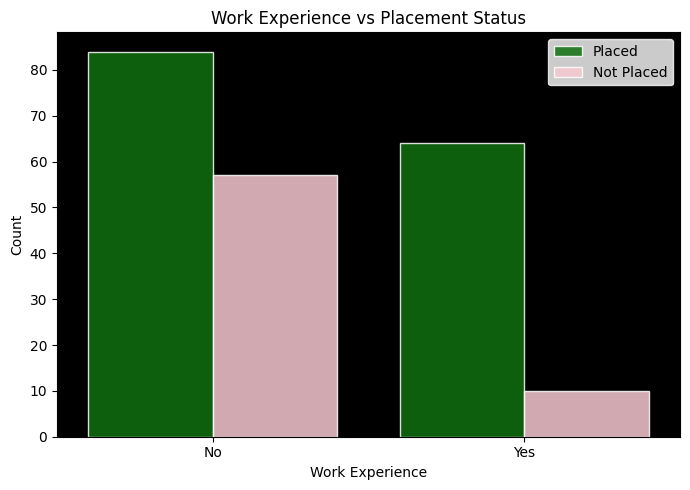

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('black')

sns.countplot(
    data    = dataset,
    x       = 'workex',
    hue     = 'status',
    palette = {'Placed': 'green', 'Not Placed': 'pink'},
    edgecolor = 'white',
    alpha   = 0.85,
    ax      = ax
)

ax.set_xlabel('Work Experience')
ax.set_ylabel('Count')
ax.set_title('Work Experience vs Placement Status')
ax.legend(
    ['Placed', 'Not Placed'],
    facecolor = 'white',
    edgecolor = 'white'
)
plt.tight_layout()
plt.show()

Students with work experience have a dramatically lower not_placement rate